<a href="https://colab.research.google.com/github/sandya-1210/Predictive_Analytics/blob/main/customer_churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  CUST00001  Female              0     Yes         No       2          Yes   
1  CUST00002    Male              0     Yes         No      37           No   
2  CUST00003  Female              0      No        Yes      26          Yes   
3  CUST00004  Female              0     Yes         No       9           No   
4  CUST00005  Female              0     Yes         No      52          Yes   

      MultipleLines InternetService       OnlineSecurity  ...  \
0  No phone service             DSL                   No  ...   
1               Yes             DSL                   No  ...   
2               Yes     Fiber optic  No internet service  ...   
3                No             DSL                  Yes  ...   
4               Yes     Fiber optic                  Yes  ...   

      DeviceProtection          TechSupport          StreamingTV  \
0                  Yes  No internet service  No internet service  

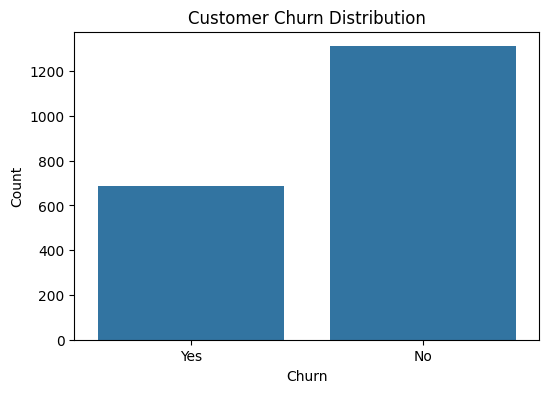

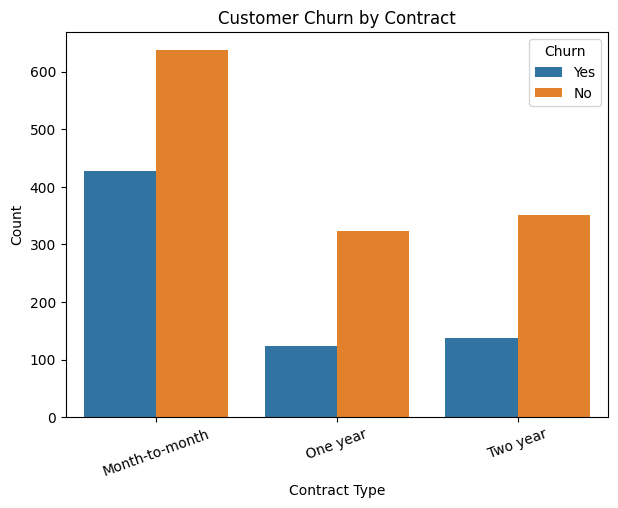

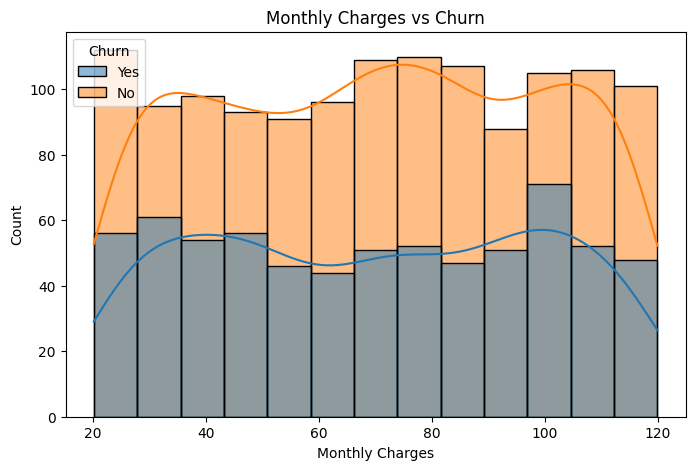


Accuracy: 0.655

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.93      0.78       262
           1       0.50      0.14      0.22       138

    accuracy                           0.66       400
   macro avg       0.59      0.53      0.50       400
weighted avg       0.61      0.66      0.58       400



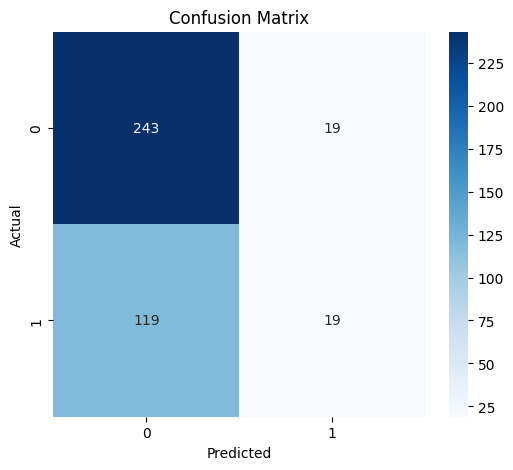

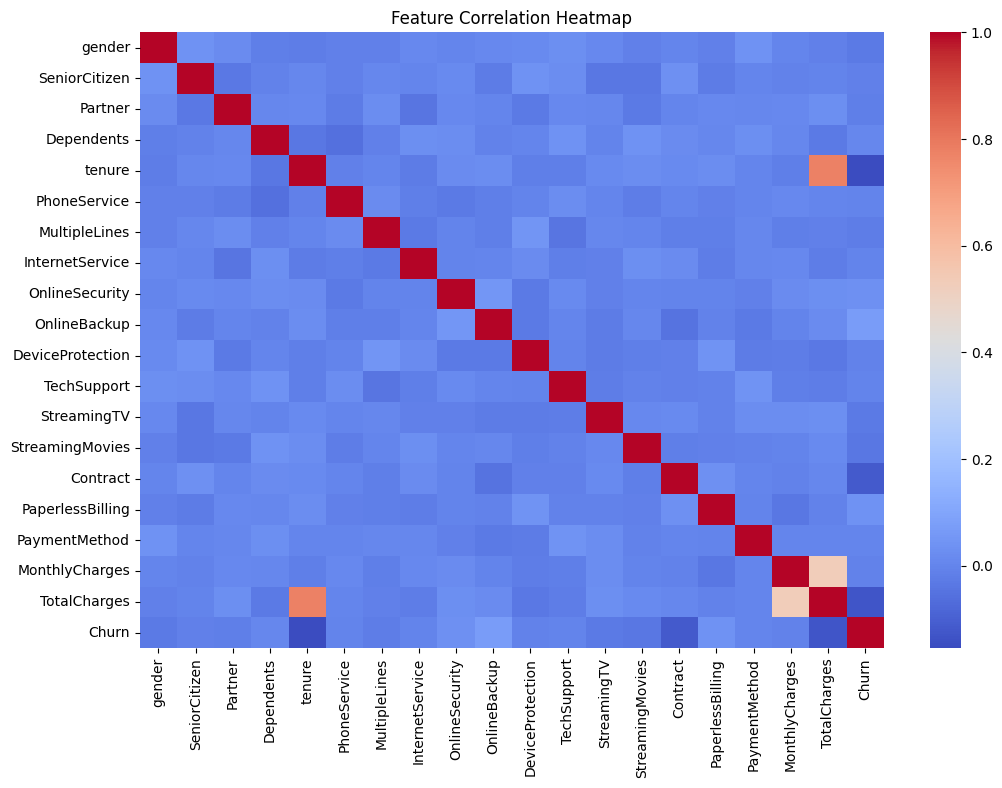

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv("customer_churn.csv")

print(df.head())
print("Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(7,5))
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Customer Churn by Contract")
plt.xlabel("Contract Type")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(data=df, x="MonthlyCharges", hue="Churn", kde=True)
plt.title("Monthly Charges vs Churn")
plt.xlabel("Monthly Charges")
plt.ylabel("Count")
plt.show()

le = LabelEncoder()

for column in df.select_dtypes(include="object").columns:
    if column != "customerID":
        df[column] = le.fit_transform(df[column])

df = df.drop("customerID", axis=1)

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()